# Orange County Analysis

In [1]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    policing_summary_table,
    prosecution_rates_by_statute_level,
    visualize_policing,
    visualize_prosecution,
    save_policing,
    save_prosecution
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
# Load in policing data
full_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2023.csv")

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = full_policing[[c for c in keep_cols if c in full_policing.columns]].copy()

# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])]

<positron-console-cell-2>:2: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
# Load in census data
census = load_census("06059")

# Policing Analysis

In [5]:
# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Adds counts, rates, and per-capita rates for stops, searches, and hits
policing_analysis = policing_summary_table(policing, census_coarse)

policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2019,Asian,3001,111,53,0.036988,0.477477,699124,4.292515,0.158770
1,2019,Black/African American,1785,257,102,0.143978,0.396887,49304,36.203959,5.212559
2,2019,Hispanic/Latino,14412,2047,806,0.142034,0.393747,1086834,13.260535,1.883452
3,2019,Other,3613,116,46,0.032106,0.396552,153072,23.603272,0.757813
4,2019,White,23042,2480,1160,0.107630,0.467742,1198655,19.223213,2.068986
5,2020,Asian,2356,123,54,0.052207,0.439024,699124,3.369932,0.175934
6,2020,Black/African American,1381,217,108,0.157133,0.497696,49304,28.009898,4.401266
7,2020,Hispanic/Latino,11782,2023,885,0.171703,0.437469,1086834,10.840662,1.861370
8,2020,Other,2632,135,56,0.051292,0.414815,153072,17.194523,0.881938
9,2020,White,16917,1955,1015,0.115564,0.519182,1198655,14.113319,1.630995


In [6]:
# Generates policing table, excluding searches that have any nondiscretionary search bases
discretionary_policing_analysis = policing_summary_table(policing[policing["search_type"].isin(["No search basis", "Discretionary only"])], census_coarse)
discretionary_policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2019,Asian,2962,72,43,0.024308,0.597222,699124,4.236731,0.102986
1,2019,Black/African American,1694,166,74,0.097993,0.445783,49304,34.358267,3.366867
2,2019,Hispanic/Latino,13839,1474,617,0.106511,0.418589,1086834,12.733315,1.356233
3,2019,Other,3576,79,33,0.022092,0.417722,153072,23.361555,0.516097
4,2019,White,22263,1701,899,0.076405,0.528513,1198655,18.573318,1.419091
5,2020,Asian,2309,76,36,0.032915,0.473684,699124,3.302705,0.108707
6,2020,Black/African American,1304,140,71,0.107362,0.507143,49304,26.448158,2.839526
7,2020,Hispanic/Latino,11268,1509,682,0.133919,0.451955,1086834,10.367729,1.388437
8,2020,Other,2601,104,46,0.039985,0.442308,153072,16.992004,0.679419
9,2020,White,16347,1385,774,0.084725,0.558845,1198655,13.637786,1.155462


## Prosecution Rates

In [7]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Enhancement Rate
0,Asian,2021,Felony,1251,0.000799
1,Asian,2021,Misdemeanor,2768,0.142702
2,Asian,2022,Felony,1090,0.003670
3,Asian,2022,Misdemeanor,2289,0.174749
4,Asian,2023,Felony,876,0.001142
5,Asian,2023,Misdemeanor,1325,0.163774
6,Black/African American,2021,Felony,1689,0.008289
7,Black/African American,2021,Misdemeanor,3014,0.112143
8,Black/African American,2022,Felony,2195,0.006834
9,Black/African American,2022,Misdemeanor,2881,0.112114


# Visualizations

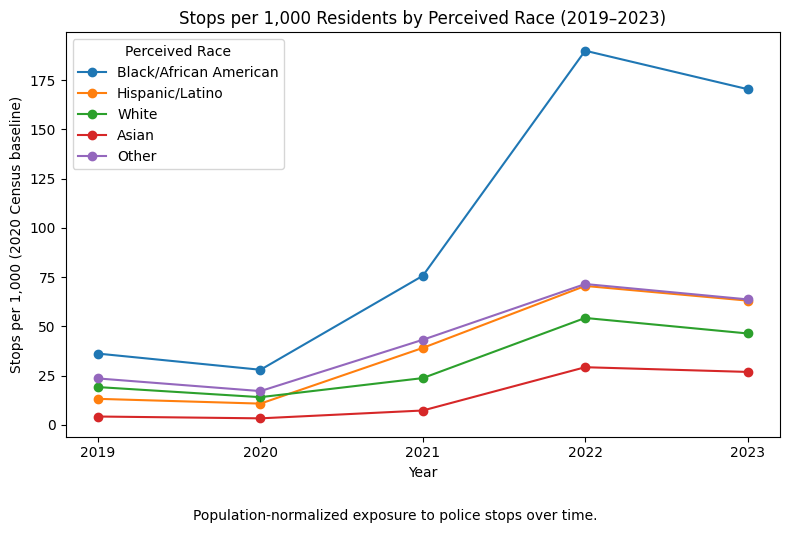

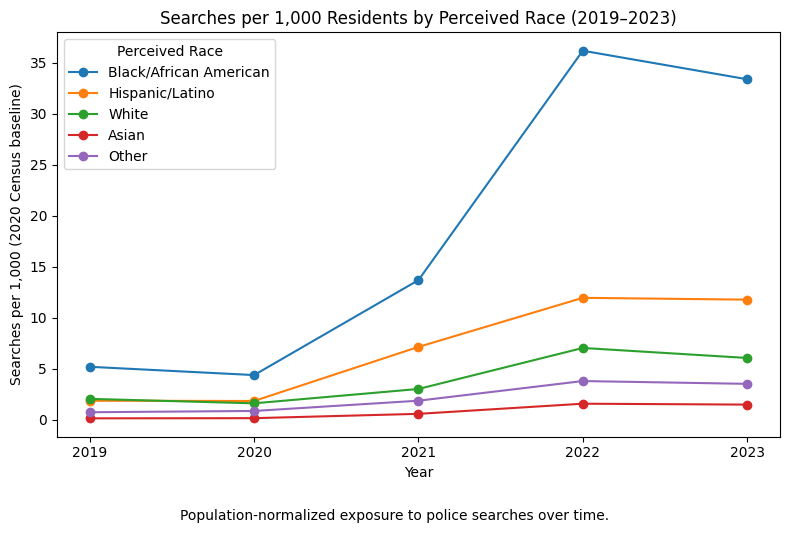

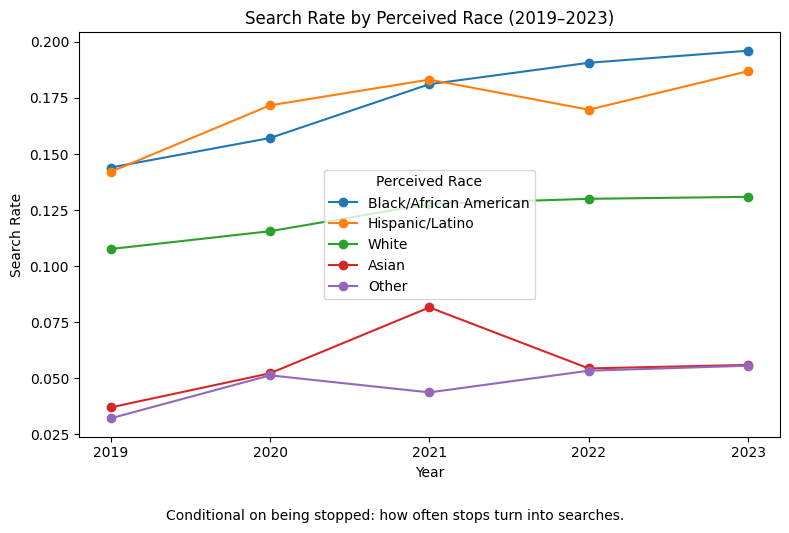

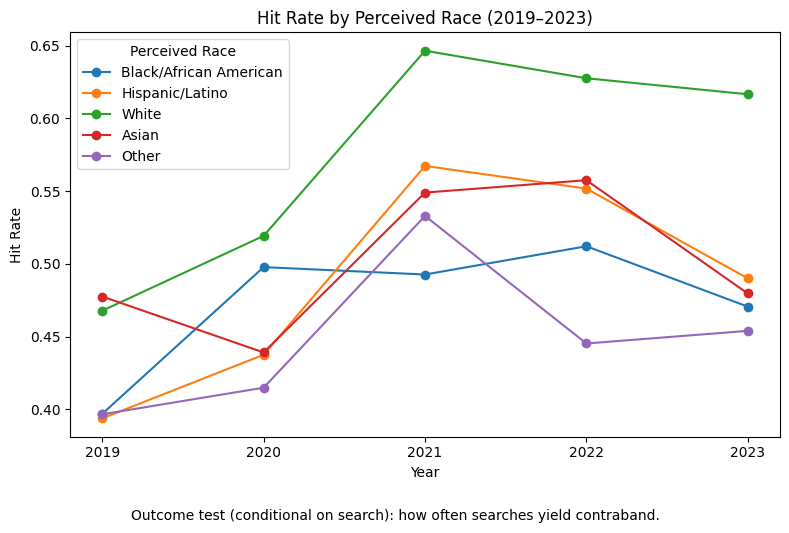

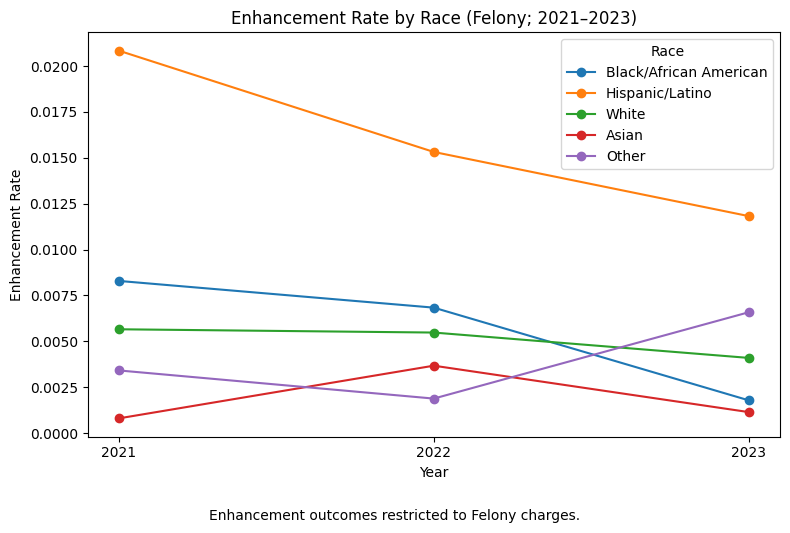

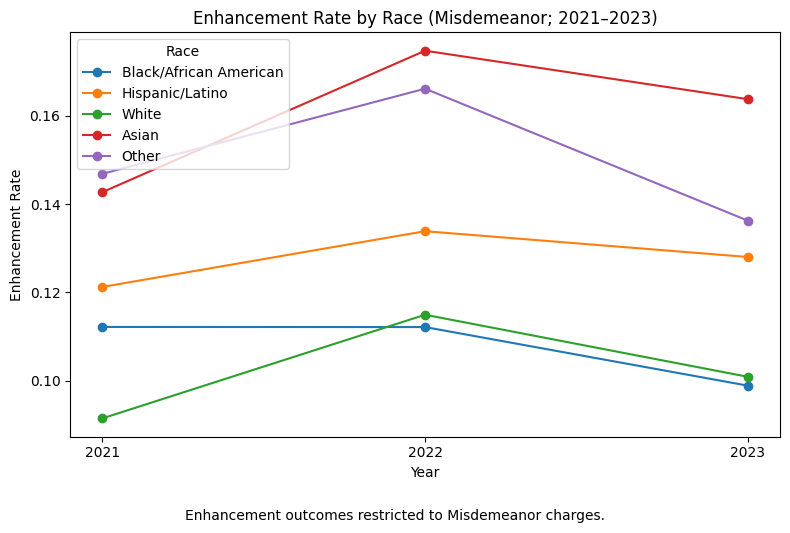

In [8]:
visualize_policing(policing_analysis)
visualize_prosecution(prosecution_analysis)

In [9]:
#save_policing(policing_analysis)
#save_prosecution(prosecution_analysis)

In [ ]:
# Saves the tables
#with open("../output/policing_analysis.tex", "w") as f:
#    f.write(policing_analysis.to_latex(index=False))

#with open("../output/prosecution_analysis.tex", "w") as f:
#    f.write(prosecution_analysis.to_latex(index=False))